# Module 4 — The FUR Regulon: Literature to Motif

**Lab context:** *E. coli* K-12 | bowtie2 | MEME Suite | Biopython | FUR transcription factor

---

This module connects a published dataset to a motif analysis pipeline:

1. **Understanding the literature** — read a real ChIP-exo paper and extract biological context.
2. **RNA-seq paired-end alignment** — the foundational read-alignment step (extends Module 3), applied to the study's transcriptome data.
3. **Motif discovery with MEME** — given a set of genomic sequences, MEME finds overrepresented patterns.
4. **Sequence extraction with Biopython** — pull binding-site sequences from the *E. coli* K-12 genome by coordinate.
5. **TSS distance analysis** — compute distances between binding sites and transcription start sites.

---

**Learning objectives:**
- Understand a real ChIP-exo study and the data it produced
- Use Biopython to extract genomic sequences by coordinate from a public dataset
- Run MEME and interpret motif output (E-value, logo shape)
- Download and align **paired-end RNA-seq** reads with bowtie2, and turn them into a GFF track
- Compute TSS distances as a downstream regulatory analysis


## Background: Transcription Factors, FUR, and Motifs

### What is a transcription factor?

A **transcription factor (TF)** is a protein that binds to specific short DNA sequences near a gene and controls whether that gene gets expressed. Think of it as a light switch wired into the chromosome: when the TF binds, it turns the gene on (or off). Bacteria like *E. coli* use hundreds of TFs to respond to changing conditions — temperature, nutrients, stress.

### What is FUR?

**FUR** (Ferric Uptake Regulator) is one of the most-studied TFs in *E. coli*. Its job is to sense how much iron is available in the cell and adjust gene expression accordingly:

- **Iron-replete (plenty of iron):** FUR binds its target sites and *represses* iron-uptake genes (no need to import more iron)
- **Iron-depleted (low iron):** FUR releases its targets, allowing iron-uptake genes to be expressed

Iron is essential for most cellular processes but toxic in excess — FUR is the cell's main iron thermostat. It controls roughly 90 genes in *E. coli*.

### What is a regulon?

A **regulon** is the complete set of genes controlled by one TF. The FUR regulon = all genes whose expression is directly regulated by FUR binding. Mapping a regulon requires knowing *where* FUR binds — which is exactly what ChIP-exo (Module 3) measures.

### What is a DNA binding motif?

When a TF binds DNA, it doesn't land randomly — it recognizes a specific short sequence pattern, typically 15–20 bp. This pattern is the TF's **binding motif**. For FUR it's called the **Fur box**. If you look at all the genomic sites where FUR binds, you expect to find the same short sequence pattern repeated at each one.

**MEME** is the tool that discovers this pattern automatically: it takes a set of sequences (your ChIP-exo peaks) and finds the motif that appears more often than chance would predict.

---

## 1. The FUR Regulon — Seo et al. 2014

The FUR binding site data used in this module comes from a real published study:

> **Seo SW, Kim D, Latif H, O'Brien EJ, Szubin R, Palsson BO (2014)** — *Deciphering Fur transcriptional regulatory network highlights its complex role beyond iron metabolism in Escherichia coli* — ***Nature Communications*** 5:4910.
> PMID: 25222563 | PMC: https://pmc.ncbi.nlm.nih.gov/articles/PMC4167408/ | DOI: 10.1038/ncomms5910 | GEO: **GSE54901**

The study used ChIP-exo to map Fur-binding sites genome-wide across different iron conditions.

**Two different things live in two different places — this matters for the exercises:**
- **Raw ChIP-exo signal** is deposited at GEO (**GSE54901**), as per-base *coverage tracks* (one row per genomic position). This is what you align to and visualize — it is **not** a list of binding sites.
- **The discrete binding-site coordinates** (the 144 called peaks, with their target genes and signal strengths) are in the paper's **Supplementary Data** table (an Excel file), *not* on GEO. This table is the input to your MEME analysis in Exercise 5.


### Exercise 1 — Understand the paper and its data

Read Seo et al. 2014 (PMC4167408) — or use Claude Code to help you understand it — and write a **3-sentence summary** in the cell below covering:
- What experiment was done, in what organism, and under what conditions
- How many FUR binding sites were identified and what regulatory modes (categories) were described
- Where the discrete binding-site coordinates are found (which supplementary table), and — separately — what kind of data GEO GSE54901 actually holds

In Exercise 5 you will download the **supplementary binding-site table** from the paper and use its coordinates as the input to motif discovery.


> **Answer**
>
> 이 연구는 Escherichia coli K-12 MG1655를 대상으로 iron-replete(0.1 mM FeCl₂)와 iron-starvation(0.2 mM 2,2′-dipyridyl) 조건에서 Fur ChIP-exo, RNAP ChIP-exo, RNA-seq를 수행하여 Fur의 직접적인 전사 조절 네트워크를 재구성하였다.  
>
> 분석 결과 총 119개의 Fur binding site가 확인되었으며, 이 중 81개 유전자(42개 transcription units)가 direct regulon으로 확정되었고, 조절 방식은 holo-Fur repression(HR), holo-Fur activation(HA), apo-Fur activation(AA)의 세 가지였으며 apo-Fur repression(AR)은 관찰되지 않았다.  
>
> Binding site의 좌표와 peak annotation은 Supplementary Data 1에 제공되며, GEO GSE54901에는 ChIP-exo와 RNA-seq의 raw sequencing/coverage 데이터가 저장되어 있어, 전자는 discrete peak 좌표, 후자는 원시 시퀀싱 신호라는 점을 구분해야 한다. 


## 2. RNA-seq: Paired-End Alignment with `bowtie2`

So far you've worked with **ChIP-exo** data (single-end). The same Fur study also produced **RNA-seq** data — a *second data type* and your first **paired-end** alignment.

Paired-end sequencing reads **both ends** of each DNA fragment, producing two FASTQ files per sample (`_1` = R1, `_2` = R2). `bowtie2` aligns them together (`-1`/`-2`), using the known fragment-size range to place reads more accurately than single-end. In this section you'll download an RNA-seq sample, align it paired-end, and turn it into a GFF — the same pipeline shape as Module 3, but for a new data type.

**Data:** the RNA-seq sub-series of the Fur study is **GEO GSE54900** (same paper, *Nature Communications* 5:4910). In the original lab workflow the paired-end sample `SRR1168133` was aligned with `bowtie2 --very-fast -X 1000 -3 3` (paired-end), then sorted and converted to GFF with `makegff.py`.


### Exercise 2 — Run a paired-end RNA-seq alignment

**Step 1 — Get a paired-end RNA-seq sample.**
Use Claude Code to navigate to the RNA-seq series and pick one paired-end sample:
```
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE54900
```
Ask Claude Code to help you:
1. Find a **paired-end** RNA-seq run in GSE54900 and get its SRR accession.
2. Download it with `fastq-dump --split-files <SRR>` (or `fasterq-dump`) — paired-end gives you **two** files, `<SRR>_1.fastq` and `<SRR>_2.fastq`.

**Step 2 — Align paired-end.**
Reuse the *E. coli* K-12 bowtie2 index you built in Module 3. Run a **paired-end** alignment — note the `-1`/`-2` inputs (not a single `-U`):
```bash
bowtie2 --very-fast -X 1000 -3 3 -p 2 \
    -x <index_prefix> \
    -1 <SRR>_1.fastq -2 <SRR>_2.fastq \
    -S <SRR>.sam
```
Then `samtools view -bS` → `samtools sort` → `samtools index`, exactly as in Module 3.

**Step 3 — Make a GFF for the RNA-seq data.**
Run the lab's provided `makegff.py` (at the repo root, the same script Module 3's pipeline used) on the sorted BAM to produce a coverage GFF. **This is RNA-seq, so add `--flip`** — RNA-seq reads report the strand *opposite* the transcript they came from, and `--flip` corrects the strand assignment (for ChIP-exo in Module 3 you omitted it):
```bash
python makegff.py --separate_strand --flip data/reference/<SRR>.sorted.bam data/reference/rnaseq.gff
```
This GFF loads into **MetaScope** alongside the gene annotation to visualize transcription — the same way you visualized the ChIP-exo track. Because `makegff.py` hardcodes `NC_000913` in column 1, it lines up with the annotation automatically.

**Step 4 — Explain the flags.** In the Answer cell, write a **one-sentence explanation for each** flag below (focus on *why*, not just mechanics), drawing on what you saw when you ran the alignment:
- `-X 1000` (maximum fragment/insert size — a paired-end-only flag)
- `-3 3` (3′ trimming)
- `--no-mixed` and `--no-discordant` (paired-end concordance)

Also answer: **why is `-X` meaningless for the single-end ChIP-exo alignment in Module 3, but important here?** what would go wrong downstream if you forgot `--no-discordant`? And: **why does the RNA-seq `makegff.py` need `--flip` when the ChIP-exo one didn't?**

> **Single-end vs paired-end:** Module 3 aligned ChIP-exo reads with a single `-U` input. Here you use `-1`/`-2`. If you accidentally pass paired files to `-U`, bowtie2 treats them as unpaired and every `-X`/concordance flag is silently ignored — a common and quiet mistake.

Write your working pipeline in the code cell below (or run it in the terminal and paste the commands here).


In [1]:
%%bash
# Paired-end RNA-seq pipeline (GSE54900) — fill in the commands after generating them with
# Claude Code. This is a bash cell: the FIRST line MUST be %%bash, or Jupyter will try to
# run these shell commands as Python and fail with a SyntaxError.
# Run from the repo root (the notebook's working directory); reads/outputs live in data/reference/.

# Step 1: Download the paired-end RNA-seq sample (fastq-dump --split-files -> _1.fastq / _2.fastq)


# Step 2: Align paired-end reads, reusing the Module 3 bowtie2 index (-1/-2, not -U)


# Step 3: SAM -> sorted, indexed BAM (samtools view / sort / index)


# Step 4: Provided root makegff.py on the sorted BAM (RNA-seq -> --separate_strand --flip)
# python makegff.py --separate_strand --flip data/reference/<SRR>.sorted.bam data/reference/rnaseq.gff


In [7]:
%%bash
export PATH="/opt/sratoolkit/bin:$PATH"

# Step 1: Download the paired-end RNA-seq sample (fastq-dump --split-files -> _1.fastq / _2.fastq)
fasterq-dump --split-files SRR1168133 -O ../data/reference/

spots read      : 10,848,313
reads read      : 21,696,626
reads written   : 21,696,626


In [8]:
%%bash
# ../data/reference 폴더에 두 파일이 생겼는지 확인
ls -lh ../data/reference/SRR1168133_*.fastq

-rw-rw-r-- 1 vscode vscode 1.5G Aug 11 06:54 ../data/reference/SRR1168133_1.fastq
-rw-rw-r-- 1 vscode vscode 1.5G Aug 11 06:54 ../data/reference/SRR1168133_2.fastq


In [9]:
%%bash 
# module3에서 만든 bowtie2 index 이름 확인
ls -lh ../data/reference/*.bt2

-rw-rw-rw- 1 vscode vscode 5.5M Aug  3 08:40 ../data/reference/NC_000913.3.1.bt2
-rw-rw-rw- 1 vscode vscode 1.2M Aug  3 08:40 ../data/reference/NC_000913.3.2.bt2
-rw-rw-rw- 1 vscode vscode   17 Aug  3 08:40 ../data/reference/NC_000913.3.3.bt2
-rw-rw-rw- 1 vscode vscode 1.2M Aug  3 08:40 ../data/reference/NC_000913.3.4.bt2
-rw-rw-rw- 1 vscode vscode 5.5M Aug  3 08:40 ../data/reference/NC_000913.3.rev.1.bt2
-rw-rw-rw- 1 vscode vscode 1.2M Aug  3 08:40 ../data/reference/NC_000913.3.rev.2.bt2


In [ ]:
%%bash
# step2 bowtie2로 정렬 (module3에서 만든 index를 재사용)
bowtie2 --very-fast -X 1000 -3 3 -p 2 --no-mixed --no-discordant \
  -x ../data/reference/NC_000913.3 \
  -1 ../data/reference/SRR1168133_1.fastq -2 ../data/reference/SRR1168133_2.fastq \
  -S ../data/reference/SRR1168133.sam

[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
10848313 reads; of these:
  10848313 (100.00%) were paired; of these:
    640168 (5.90%) aligned concordantly 0 times
    9891156 (91.18%) aligned concordantly exactly 1 time
    316989 (2.92%) aligned concordantly >1 times
94.10% overall alignment rate


In [11]:
%%bash
# step3.SAM -> sorted, indexed BAM 
samtools view -bS ../data/reference/SRR1168133.sam -o ../data/reference/SRR1168133.bam
samtools sort ../data/reference/SRR1168133.bam -o ../data/reference/SRR1168133_sorted.bam
samtools index ../data/reference/SRR1168133_sorted.bam

[bam_sort_core] merging from 5 files and 1 in-memory blocks...


In [12]:
%%bash
# 나눈 임시파일 5개 확인
ls -lh ../data/reference/SRR1168133*.bam*

-rw-rw-rw- 1 vscode vscode 759M Aug 11 07:29 ../data/reference/SRR1168133.bam
-rw-rw-rw- 1 vscode vscode 468M Aug 11 07:31 ../data/reference/SRR1168133_sorted.bam
-rw-rw-rw- 1 vscode vscode  14K Aug 11 07:31 ../data/reference/SRR1168133_sorted.bam.bai


In [14]:
%%bash
# makegff.py로 RNA-seq coverage GFF 생성

python ../makegff.py --separate_strand --flip --log_scale ../data/reference/SRR1168133_sorted.bam ../data/reference/rnaseq.gff

In [ ]:
%%bash
# 몇 줄이 생겼는지, 포맷 예상값 확인
wc -l ../data/reference/rnaseq.gff
head -5 ../data/reference/rnaseq.gff

7261516 ../data/reference/rnaseq.gff
NC_000913		SRR1168133_sorted.bam_(-)	356	356	0.00	-	.	.
NC_000913		SRR1168133_sorted.bam_(-)	357	357	0.00	-	.	.
NC_000913		SRR1168133_sorted.bam_(-)	358	358	0.00	-	.	.
NC_000913		SRR1168133_sorted.bam_(-)	359	359	0.00	-	.	.
NC_000913		SRR1168133_sorted.bam_(-)	360	360	0.00	-	.	.


In [16]:
%%bash
# 실제 유전자 있는 구간 확인, score가 0보다 큰 줄 살펴보기
awk '$6+0 > 0' ../data/reference/rnaseq.gff | head -5

> **Answer**
>
> **`-X 1000`:** Sets the maximum allowed insert size to 1000 bp, so only read pairs within this distance are considered properly paired.
>
> **`-3 3`:**  Trims 3 bases from the 3′ end of each read before alignment to reduce errors caused by low-quality bases.
>
> **`--no-mixed` / `--no-discordant`:** Prevents Bowtie2 from reporting alignments where only one mate maps while the other fails to align./ Prevents Bowtie2 from reporting read pairs that both align but have an unexpected orientation or insert size.
>
> **Why `-X` matters here but not in Module 3 (single-end):** -X is only relevant for paired-end sequencing because it defines the maximum distance allowed between the two mates, whereas single-end reads have no mate.
>
> **What goes wrong without `--no-discordant`:** Discordant read pairs can be treated as valid alignments, causing incorrectly paired genomic regions to contribute to coverage and potentially distorting the coverage tracks generated by makegff.py.
> Why RNA-seq makegff.py needs --flip but ChIP-exo does not: RNA-seq libraries are strand-specific and the sequenced reads can correspond to the strand opposite the original transcript due to the library preparation method, so --flip is needed to recover the correct transcription strand, whereas ChIP-exo sequences genomic DNA directly and therefore does not require strand flipping.


## 3. How MEME Works

### What problem does MEME solve?

You have 90 genomic sequences — one around each FUR binding site. If FUR binds a specific sequence pattern (the Fur box), that pattern should appear in most of your sequences. But you don't know in advance *what* the pattern looks like or exactly *where* in each sequence it sits.

**MEME** (Multiple Em for Motif Elicitation) finds overrepresented sequence patterns in a set of input sequences without knowing what to look for. It uses an algorithm called Expectation-Maximization (EM) to iteratively refine a motif model until it fits the data as well as possible.

### What is an E-value?

The **E-value** answers: *"How many times would I expect to find a motif this good by random chance in a dataset this size?"*

- E-value of 10⁻²⁰ → extremely unlikely by chance → strong, real motif
- E-value of 1.5 → you'd expect to see this pattern 1–2 times by chance → likely noise

For a real TF binding motif like the Fur box, expect E-values well below 10⁻¹⁰. If your top motif has an E-value above 0.01, something may be wrong with your input sequences (wrong coordinates, wrong organism, mixed conditions).

Use Claude Code to understand how the EM algorithm works and what the E-value measures before running MEME.

### Exercise 3 — Understand MEME in your own words

Use Claude Code to explore the MEME algorithm and E-value interpretation. Then write a **3-sentence summary in your own words** — not copied from Claude's output, but re-stated in your own understanding.

> Focus on: what problem EM is solving, what E-value measures, and why motif width matters.

> **Answer**
>
> MEME는 EM 알고리즘을 이용해 모티프의 서열(PWM) 과 각 서열에서 모티프의 위치라는 두 가지 미지수를 E-step(위치 확률 계산) 과 M-step(PWM 재추정) 을 반복하며 동시에 추정한다. 
>
> E-value는 발견된 모티프가 무작위 데이터에서도 우연히 나타날 것으로 기대되는 횟수를 의미하며, 값이 작을수록 통계적으로 더 신뢰할 수 있는 모티프임.
>
> Motif width는 너무 짧으면 실제 결합 서열의 일부만 포함하고, 너무 길면 불필요한 주변 서열이 섞여 신호가 희석되므로 적절한 폭을 설정하는 것이 중요함


### Exercise 4 — Conceptual prediction (answer before asking Claude)

**Without asking Claude Code first:** predict what the MEME output would look like for each of these two inputs:

(a) 10 **random** 200 bp genomic sequences from *E. coli* K-12  
(b) 10 **real FUR binding site** sequences (±50 bp around known sites)

For each case, predict: approximate E-value range, whether a clear motif logo would appear, and what width you would expect.

Write your prediction below. Then verify your reasoning with Claude Code and note where you were right or wrong.

*Your prediction here (before checking with Claude Code).*
> (a)에서는 실제로 공유되는 binding motif가 없기 때문에 MEME가 우연히 반복되는 짧은 패턴을 잡더라도 E-value가 높고 motif logo도 약하며, 반복 실행이나 샘플에 따라 width가 쉽게 달라질 것으로 예상함. 
> 
> 반면 (b)에서는 10개 서열 모두 실제 Fur binding site 주변에서 가져왔기 때문에 공통적인 Fur box sequence가 같은 위치적·서열적 패턴으로 반복되고, 더 낮은 E-value와 뚜렷한 sequence logo가 나타날 가능성이 높고 약 15–20 bp 정도의 motif가 잡힐 것으로 예상함.
>
> 특히 이 논문에서도 holo-Fur repression motif가 canonical 7-1-7 Fur-box 구조를 포함한 약 15 bp 패턴으로 나타났기 때문에, (b)의 결과가 이 근처로 나오면 꽤 유의할 것 같음. 다만 E-value 숫자는 데이터 10개뿐이라 상당히 변동성이 크기때문에, 위 범위는 어디까지나 검증 전 가설로 생각해야 함.
---

*Verification notes (after checking with Claude Code):*
> (a) 검증: 실제로 E. coli K-12 MG1655 (NC_000913.3)에서 무작위 200 bp 서열 10개(random_sites_for_meme.fasta)를 추출하여 동일한 MEME 파라미터로 분석한 결과, 세 개의 모티프의 E-value가 각각 1.1×10², 3.1×10², 7.8×10³으로 모두 매우 높아 통계적으로 유의하지 않았으며(노이즈 기준인 E-value ≈ 1.5보다도 훨씬 큼), consensus 서열에도 IUPAC 모호 코드(S, K, V, M, B, N, W 등) 가 다수 포함되어 특정 염기의 보존성이 거의 없음을 확인함. 또한 motif width는 21, 21, 15 bp로 일정한 길이에 수렴하지 않아, 무작위 서열에서는 일관된 결합 모티프가 존재하지 않는다는 예측과 일치함.


In [22]:
# MEME motif 탐색 프로그램 돌리기 (random_sites_for_mem.fasta를 MEME에 입력으로 넣어서 이 10개 서열 안에 동통으로 반복되는 모티프 있는지 확인해보기)
import random
from Bio import SeqIO

record = SeqIO.read("../data/reference/NC_000913.3.fasta", "fasta")
genome = record.seq
genome_len = len(genome)

random.seed(42)  # 재현 가능하게 고정

records = []
for i in range(10):
    start = random.randint(0, genome_len - 200)
    seq = genome[start:start+200]
    records.append((f"random_{i}_{start}", str(seq)))

with open("../data/reference/random_sites_for_meme.fasta", "w") as f:
    for name, seq in records:
        f.write(f">{name}\n{seq}\n")

print(f"{len(records)} random sequences written to random_sites_for_meme.fasta")

10 random sequences written to random_sites_for_meme.fasta


In [23]:
%%bash
/opt/meme/bin/meme ../data/reference/random_sites_for_meme.fasta \
  -dna -oc ../data/reference/meme_random_control \
  -mod zoops -minw 15 -maxw 25 -nmotifs 3 -revcomp

The output directory '../data/reference/meme_random_control' already exists.
Its contents will be overwritten.
BACKGROUND: using background model of order 0
PRIMARY (classic): n 10 p0 10 p1 0 p2 0
SEQUENCE GROUP USAGE-- Starts/EM: p0; Trim: p0; pvalue: p0; nsites: p0,p1,p2
SEEDS: maxwords 2000 highwater mark: seq 10 pos 185
Initializing the motif probability tables for 2 to 10 sites...
nsites = 10
Done initializing.

seqs=    10, min_w= 200, max_w=  200, total_size=     2000

motif=1
SEED DEPTHS: 2 4 8 10
SEED WIDTHS: 15 21 25
em: w=  25, psites=  10, iter=   0 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.

motif=2
SEED DEPTHS: 2 4 8 10
SEED WIDTHS: 15 21 25
em: w=  25, psites=  10, iter=   0 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.

motif=3
SEED DEPTHS: 2 4 8 10
SEED WIDTHS: 15 21 25
em: w=  25, psites=  10, iter=   0 Warning: Cannot convert EPS file to PNG as no install of Image M

In [24]:
%%bash
# width와 E-value 확인
grep -A 1 "MOTIF" ../data/reference/meme_random_control/meme.txt

MOTIF TSCAKVMKGTGKKGMTGCCGC MEME-1	width =  21  sites =   7  llr = 111  E-value = 1.1e+002
********************************************************************************
--
SEQUENCE NAME            POSITION P-VALUE  MOTIF DIAGRAM
-------------            ----------------  -------------
--
BL   MOTIF TSCAKVMKGTGKKGMTGCCGC width=21 seqs=7
random_0_933912          (  154) TGCACGCGGTGTGGCTGCCGA  1 
--
MOTIF GBKRMTBGMWNWBGCYGAAVA MEME-2	width =  21  sites =  10  llr = 128  E-value = 3.1e+002
********************************************************************************
--
SEQUENCE NAME            POSITION P-VALUE  MOTIF DIAGRAM
-------------            ----------------  -------------
--
BL   MOTIF GBKRMTBGMWNWBGCYGAAVA width=21 seqs=10
random_8_729295          (    3) GTGGATGGATCAGGCCGAAAA  1 
--
MOTIF GCGCTTTTTCVSNTC MEME-3	width =  15  sites =  10  llr = 103  E-value = 7.8e+003
********************************************************************************
--
SEQUENCE NAME           

> 
> **E-value**:지문에서 E-value가 1.5정도면 우연히 1~2번 나올 정도의 노이즈라고 했는데, 지금 나온 값들은 100~7800정도로 노이즈 기준보다 훨씬 높음 -> 이는 "모트프"들은 통계적으로 의미 없고, MEME가 의도적으로 뭔가를 출력한 거라고 생각함. (예측과 동일)
> 
> **width**: 21,21,15 - minw/maxw 범위 안에서 나오긴 했으나 일정값으로 수렴하지 않고 들쭉날쭉함. (예측과 동일)
>
> **Consensus 서열 모양**: IUPAC 모호 코드 (S, K, V, M, B, N, W...)이 많음 -> 이는 특정 위치에서 뚜렷하게 우세한 염기가 없다는 뜻으로 흐릿하고 애매한 모양이 나올 것으로 생각함


## 4. Extracting Sequences with Biopython

The Fur-binding site coordinates come from the **Supplementary Data table of Seo et al. 2014** (an Excel file you download from the paper in Exercise 5), which lists each site's `ChIP-exo Start` / `ChIP-exo End`. Use Biopython to extract DNA sequences from the *E. coli* K-12 reference FASTA at those coordinates. Handle strand correctly — reverse-complement sequences on the minus strand.


### Exercise 5 — Fetch the data and write the sequence extraction script

**Step 1 — Get the binding-site table with Claude Code:**
The discrete Fur binding sites are in the **Supplementary Data** of the Nature Communications paper, not on GEO. Give Claude Code the article page and ask it to locate and download the supplementary table:

```
https://www.nature.com/articles/ncomms5910
```

Ask Claude Code to:
1. Find the **Supplementary Data** file that contains the Fur ChIP-exo **binding sites** (target gene, `ChIP-exo Start`, `ChIP-exo End`, binding condition, S/N ratio) and download it into `data/reference/`. *(It is an Excel `.xlsx` file — the same one used in the original lab tutorial.)*
2. Download the *E. coli* K-12 reference FASTA into `data/reference/NC_000913.fasta` (same file as Module 3 — skip if already present).

**Step 2 — Read the table.** It has a title row above the real header, so read it with the header on the **second** row:
```python
import pandas as pd
df = pd.read_excel("data/reference/<supplementary_file>.xlsx", header=1)
df = df.dropna(subset=["Peak"])          # keep rows that are actual binding sites
```
Columns include: `Transcription Unit`, `Peak` (a peak **ID label** like `P1`, `P2` — *not* a score), `ChIP-exo Start`, `ChIP-exo End`, `Binding Condition` (`R` = iron-replete, `S` = iron-depleted, `R/S` = both), `S/N ratio` and `Significance (p-value)` (these are the strength/score fields), and `Distance to TSS`. Filter to the **iron-replete** sites with `Binding Condition` containing `R`.

**Step 3 — Write a Biopython script that:**
1. Reads the binding-site coordinates from the table (iron-replete sites).
2. Loads the reference FASTA.
3. Extracts sequences ±50 bp around each binding site center (center = midpoint of `ChIP-exo Start`/`End`).
4. Handles strand correctly if a strand is available (reverse complement for `-`).
5. Writes a FASTA file (`data/reference/fur_sites_for_meme.fasta`) ready for MEME input.

> **Coordinate convention warning:** the table's coordinates are **1-based**. Python string slicing is **0-based**. Off-by-one errors here silently shift every extracted sequence.

> **Genome-version note:** the paper's coordinates were called on the *E. coli* K-12 MG1655 genome. Extract from a reference FASTA consistent with those coordinates, and sanity-check a couple of sequences (e.g. does a known Fur site contain a recognizable Fur box?) before trusting all of them.

Run the script and confirm the output FASTA has about one sequence per binding site before proceeding. For reference, the table has **144** sites total; **143** are bound under the iron-replete condition (82 labelled `R` = iron-replete only, plus 61 labelled `R/S` = bound in both conditions), and only 1 is `S`-only.

Write the final working script in the code cell below.


> **Explain it:** 이 스크립트는 Supplementary Data 1에서 iron-replete 조건(Binding Conditiona에 "R" 포함, R 또는 R/S)인 143개 Fur binding site를 필터링한 뒤, 각 site의 ChIP-exo Start/End의 중간점(midpoint)을 계산하고, 그 중심을 기준으로 ±50bp(총 101bp)를 NC_000913.2 reference genome에서 추출한다. 표 좌표는 1-based inclusive이지만 Python 슬라이싱은 0-based이므로, genome[region_start - 1 : region_end]처럼 시작점에만 -1을 적용해 좌표계를 맞췄다 (이 부분을 틀리면 모든 추출 서열이 한 염기씩 밀리는 버그가 생긴다.)
> 
> genome 버전은 의도적으로 NC_000913.2를 선택했다. bowtie2 index로 이미 갖고 있던 .3을 그대로 썼다면 더 편했겠지만, 논문 Methods 섹션에 ChIP-exo와 RNA-seq 모두 .2에 매핑했다고 명시되어 있고, .2와 .3 사이에는 몇 군데 서열 교정(indel)이 있어 좌표가 밀릴 위험이 있었다. 이를 MEME 실행 전에 확인하기 위해, 논문이 "Fur box와 가장 유사하다"고 평가한 상위 5개 site(가장 낮은 Significance (p-value) of similarity to Fur box)를 뽑아 알려진 Fur box consensus(GATAATGATAATCATTATC, 19bp)와 비교하는 positive control을 수행했다. 5개 site 모두 3~4/19 mismatch로 잘 일치해, .2 genome 선택과 좌표 변환 로직이 정확함을 MEME을 돌리기 전에 확인할 수 있었다.
>
> strand 컬럼이 표에 없어 모든 site를 +로 간주했는데, 이는 결과에 편향을 주지 않는다 — 다음 섹션에서 MEME을 -revcomp 옵션으로 실행하기 때문에, 입력 서열이 어느 strand로 기록됐든 양쪽 가닥을 모두 탐색하게 된다.

In [1]:
%%bash
# 다운로드 파일 확인
export PATH="/opt/sratoolkit/bin:$PATH"

# NC_000913.2 (E. coli K-12 MG1655, 논문 좌표 기준 버전) 다운로드
curl -o ../data/reference/NC_000913.2.fasta \
  "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_000913.2&rettype=fasta&retmode=text"

# 다운로드 확인
ls -lh ../data/reference/NC_000913.2.fasta
head -1 ../data/reference/NC_000913.2.fasta

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 4595k    0 4595k    0     0  1944k      0 --:--:--  0:00:01 --:--:--  222k-- --:--:-- --:--:--     0   0 --:--:--  0:00:02 --:--:-- 1945k


-rw-rw-rw- 1 vscode vscode 4.5M Aug 12 02:34 ../data/reference/NC_000913.2.fasta
>NC_000913.2 Escherichia coli str. K-12 substr. MG1655, complete genome


In [2]:

from Bio import SeqIO
record = SeqIO.read("../data/reference/NC_000913.2.fasta", "fasta")
print(f"Genome length: {len(record.seq)} bp")

Genome length: 4639675 bp


**STEP1. supplementray Data 1 다운로드**

**STEP2. 표 읽기**

In [3]:
#pandas로 표 읽기
import pandas as pd

# 먼저 헤더 없이 읽어서 실제 구조 확인
raw = pd.read_excel("../data/reference/ncomms5910_SupplementaryData1_Fur_ChIPexo_binding_sites.xlsx", header=None, nrows=5)
print(raw)

                                                  0                   1   \
0  Supplementary Data 1.  Fur-associated regions ...                 NaN   
1                                      Binding Sites  Transcription Unit   
2                                                  1                araC   
3                                                  2                panD   
4                                                  3             fhuACDB   

     2               3             4                   5           6     7   \
0   NaN             NaN           NaN                 NaN         NaN   NaN   
1  Peak  ChIP-exo Start  ChIP-exo End  Binding Conditiona    Location  Mode   
2    P1           70524         70536                 R/S    Internal     -   
3    P2          146494        146507                   R    Internal     -   
4    P3          167242        167254                   R  regulatory    HR   

                8          9   \
0              NaN        NaN   
1 

In [4]:
# 필터링해서 읽기
import pandas as pd

df = pd.read_excel(
    "../data/reference/ncomms5910_SupplementaryData1_Fur_ChIPexo_binding_sites.xlsx",
    header=1
)
df = df.dropna(subset=["Peak"])  # 실제 binding site 행만 남김

print(f"전체 행 수: {len(df)}")
print(df["Binding Conditiona"].value_counts())  # R / S / R/S 분포 확인

전체 행 수: 144
Binding Conditiona
R      82
R/S    61
S       1
Name: count, dtype: int64


In [5]:
# Iron-replete sites (R 포함)만 필터링
df_replete = df[df["Binding Conditiona"].astype(str).str.contains("R")]
print(f"Iron-replete sites (R 포함): {len(df_replete)}")

Iron-replete sites (R 포함): 143


**STEP3. Biopython으로 서열 추출**

In [6]:
from Bio import SeqIO

# --------------------------------------------------
# 1. Step 2에서 만든 filtered dataframe 사용
# --------------------------------------------------

sites = df_replete

print("Number of binding sites:", len(sites))


# --------------------------------------------------
# 2. E. coli K-12 MG1655 reference genome 불러오기
# --------------------------------------------------

record = SeqIO.read("../data/reference/NC_000913.2.fasta", "fasta")
genome = str(record.seq)

print("Genome length:", len(genome))


# --------------------------------------------------
# 3. 각 binding site midpoint 기준 ±50 bp 추출
# --------------------------------------------------

sequences = []

for i, row in sites.iterrows():

    start = int(row["ChIP-exo Start"])   # 1-based inclusive
    end = int(row["ChIP-exo End"])       # 1-based inclusive

    midpoint = round((start + end) / 2)

    region_start = max(1, midpoint - 50)
    region_end = min(len(genome), midpoint + 50)

    # 1-based inclusive → Python 0-based slicing
    seq = genome[region_start - 1 : region_end]

    sequences.append(
        (
            f"Fur_site_{i+1}|midpoint={midpoint}|region={region_start}-{region_end}",
            seq
        )
    )


# --------------------------------------------------
# 4. FASTA 저장
# --------------------------------------------------

with open("../data/reference/fur_sites_for_meme.fasta", "w") as f:
    for header, seq in sequences:
        f.write(f">{header}\n")
        f.write(f"{seq}\n")

print("Saved:", len(sequences), "sequences")
print("Output: fur_sites_for_meme.fasta")

Number of binding sites: 143
Genome length: 4639675
Saved: 143 sequences
Output: fur_sites_for_meme.fasta


In [7]:
%%bash
# 파일 저장 위치 확인
ls -lh ../data/reference/fur_sites_for_meme.fasta
wc -l ../data/reference/fur_sites_for_meme.fasta
head -4 ../data/reference/fur_sites_for_meme.fasta

-rw-rw-rw- 1 vscode vscode 22K Aug 12 02:34 ../data/reference/fur_sites_for_meme.fasta
286 ../data/reference/fur_sites_for_meme.fasta
>Fur_site_1|midpoint=70530|region=70480-70580
CTCGATTTTTTTATCGACCGACCGCTGGGAATGAAAGGTTATATTCTCAATCTCACCATTCGCGGTCAGGGGGTGGTGAAAAATCAGGGACGAGAATTTGT
>Fur_site_2|midpoint=146500|region=146450-146550
CCGACACTGGCGCAGTGGGCCGCCGCACCGTTAACAGAAATAATTCTCGAACCGCGTTCTGCCGCGATGGCATAAGTGGAGAAACGCTTGCCGTTGGTGAC


In [8]:
# positive control 검증 코드 실행 
def reverse_complement(seq):
    return seq.translate(str.maketrans("ACGTacgt", "TGCAtgca"))[::-1]

def best_match(seq, consensus="GATAATGATAATCATTATC"):
    w = len(consensus)
    best = (0.0, "+", "")
    for strand, candidate in (("+", seq), ("-", reverse_complement(seq))):
        for i in range(len(candidate) - w + 1):
            window = candidate[i:i+w].upper()
            identity = sum(a == b for a, b in zip(window, consensus)) / w
            if identity > best[0]:
                best = (identity, strand, window)
    return best

top5 = sites.copy()
top5["pval"] = pd.to_numeric(top5["Significance (p-value) of similarity to Fur box"], errors="coerce")
top5 = top5.dropna(subset=["pval"]).sort_values("pval").head(5)

for _, row in top5.iterrows():
    start, end = int(row["ChIP-exo Start"]), int(row["ChIP-exo End"])
    midpoint = round((start + end) / 2)
    region_start = max(1, midpoint - 50)
    region_end = min(len(genome), midpoint + 50)
    seq = genome[region_start - 1: region_end]
    identity, strand, match = best_match(seq)
    mismatches = round((1 - identity) * 19)
    print(f"{row['Peak']:5s} {row['Transcription Unit']!s:15s} mismatches={mismatches}/19 strand={strand} {match}")

P82   nan             mismatches=4/19 strand=- GAATTTGATAATCATTCTC
P81   mntH            mismatches=4/19 strand=- GAATTTGATAATCATTCTC
P108  ryhB            mismatches=3/19 strand=+ GACAATAATAATCATTCTC
P109  nan             mismatches=3/19 strand=+ GACAATAATAATCATTCTC
P50   nan             mismatches=4/19 strand=- GCTAATGATAACCATTCCC


In [9]:
# Your Biopython sequence extraction script here.
import pandas as pd
from Bio import SeqIO

XLSX_PATH = "../data/reference/ncomms5910_SupplementaryData1_Fur_ChIPexo_binding_sites.xlsx"
GENOME_PATH = "../data/reference/NC_000913.2.fasta"
OUT_PATH = "../data/reference/fur_sites_for_meme.fasta"
FLANK = 50
FUR_BOX_CONSENSUS = "GATAATGATAATCATTATC"  # 19bp, Escolar et al. 1998

# Step 1~2: 표 읽기, iron-replete 필터링
df = pd.read_excel(XLSX_PATH, header=1)
df = df.dropna(subset=["Peak"])
df = df[df["Binding Conditiona"].astype(str).str.contains("R")]
print(f"Iron-replete binding sites: {len(df)}")

# Step 3: reference genome 로드
record = SeqIO.read(GENOME_PATH, "fasta")
genome = str(record.seq)
print(f"Genome length: {len(genome)} bp (NC_000913.2)")

# Step 4: 각 site 중심 ±50bp 추출
sequences = []
for i, row in df.iterrows():
    start = int(row["ChIP-exo Start"])   # 1-based inclusive
    end = int(row["ChIP-exo End"])       # 1-based inclusive
    midpoint = round((start + end) / 2)
    region_start = max(1, midpoint - FLANK)
    region_end = min(len(genome), midpoint + FLANK)
    seq = genome[region_start - 1 : region_end]  # 1-based -> 0-based
    header = f"{row['Peak']}_{row['Transcription Unit']}|midpoint={midpoint}|region={region_start}-{region_end}"
    sequences.append((header, seq))

with open(OUT_PATH, "w") as f:
    for header, seq in sequences:
        f.write(f">{header}\n{seq}\n")
print(f"Saved {len(sequences)} sequences to {OUT_PATH}")

# --- Positive control: MEME 실행 전 좌표/genome 버전 사전 검증 ---
def reverse_complement(seq):
    return seq.translate(str.maketrans("ACGTacgt", "TGCAtgca"))[::-1]

def best_match(seq, consensus=FUR_BOX_CONSENSUS):
    w = len(consensus)
    best = (0.0, "+", "")
    for strand, candidate in (("+", seq), ("-", reverse_complement(seq))):
        for j in range(len(candidate) - w + 1):
            window = candidate[j:j+w].upper()
            identity = sum(a == b for a, b in zip(window, consensus)) / w
            if identity > best[0]:
                best = (identity, strand, window)
    return best

top5 = df.copy()
top5["pval"] = pd.to_numeric(top5["Significance (p-value) of similarity to Fur box"], errors="coerce")
top5 = top5.dropna(subset=["pval"]).sort_values("pval").head(5)

print("\n--- Positive control: top 5 known strong Fur-box sites ---")
passed = 0
for _, row in top5.iterrows():
    start, end = int(row["ChIP-exo Start"]), int(row["ChIP-exo End"])
    midpoint = round((start + end) / 2)
    region_start = max(1, midpoint - FLANK)
    region_end = min(len(genome), midpoint + FLANK)
    seq = genome[region_start - 1: region_end]
    identity, strand, match = best_match(seq)
    mismatches = round((1 - identity) * len(FUR_BOX_CONSENSUS))
    ok = mismatches <= 5
    passed += ok
    print(f"  {row['Peak']:5s} {str(row['Transcription Unit']):15s} mismatches={mismatches}/19 strand={strand} {match} -> {'PASS' if ok else 'FAIL'}")
print(f"--- {passed}/{len(top5)} passed ---")
if passed < len(top5):
    print("WARNING: 일부 site가 통과하지 못했습니다. genome 버전/좌표를 재확인하세요.")

Iron-replete binding sites: 143


Genome length: 4639675 bp (NC_000913.2)
Saved 143 sequences to ../data/reference/fur_sites_for_meme.fasta

--- Positive control: top 5 known strong Fur-box sites ---
  P82   nan             mismatches=4/19 strand=- GAATTTGATAATCATTCTC -> PASS
  P81   mntH            mismatches=4/19 strand=- GAATTTGATAATCATTCTC -> PASS
  P108  ryhB            mismatches=3/19 strand=+ GACAATAATAATCATTCTC -> PASS
  P109  nan             mismatches=3/19 strand=+ GACAATAATAATCATTCTC -> PASS
  P50   nan             mismatches=4/19 strand=- GCTAATGATAACCATTCCC -> PASS
--- 5/5 passed ---


## 5. Running MEME

MEME is a command-line tool. The basic invocation is:

```bash
meme input.fasta -dna -oc output_dir -mod zoops -minw 15 -maxw 25 -nmotifs 3
```

Use **Claude Code plan mode** to generate the full command with the flags appropriate for your FUR binding site dataset. Make sure you understand each flag before running.

> **Think first:** FUR binds double-stranded DNA, so a binding motif can appear on either strand. Which MEME flag accounts for this? Write your answer before generating the command.
>
> 
>revcomp 플래그. FUR는 이중가닥 DNA에 결합하므로 모티프가 정방향 또는 역상보 가닥 어디에도 나타날 수 있음. 앞서 binding-site 표에 Strand 컬럼이 없어 모든 서열을 + 방향 기준으로만 추출했는데, 이것이 문제가 되지 않는 이유가 바로 이 플래그 때문임.
>
> revcomp를 주면 MEME이 입력 서열의 역상보 가닥까지 함께 탐색함 -> 실제 Fur box가 어느 가닥에 있든 놓치지 않는 이유.

In [ ]:
%%bash
#MEME 실행
/opt/meme/bin/meme ../data/reference/fur_sites_for_meme.fasta \
  -dna \
  -oc ../data/reference/meme_fur_out \
  -mod zoops \
  -minw 15 -maxw 25 \
  -nmotifs 3 \
  -revcomp

Writing results to output directory '../data/reference/meme_fur_out'.
BACKGROUND: using background model of order 0
PRIMARY (classic): n 143 p0 143 p1 0 p2 0
SEQUENCE GROUP USAGE-- Starts/EM: p0; Trim: p0; pvalue: p0; nsites: p0,p1,p2
SEEDS: maxwords 14443 highwater mark: seq 143 pos 86
Initializing the motif probability tables for 2 to 143 sites...
nsites = 143s = 5es = 22 30es = 39 47
Done initializing.

seqs=   143, min_w= 101, max_w=  101, total_size=    14443

motif=1
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.

motif=2
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.

motif=3
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Cannot convert EPS file 

In [ ]:
%%bash
# 3 motifs width와 E-value 확인
grep -A 1 "MOTIF" ../data/reference/meme_fur_out/meme.txt

MOTIF WTRAKAATYATTCTCAWTYWBRWY MEME-1	width =  24  sites = 141  llr = 1330  E-value = 1.7e-191
********************************************************************************
--
SEQUENCE NAME            POSITION P-VALUE  MOTIF DIAGRAM
-------------            ----------------  -------------
--
BL   MOTIF WTRAKAATYATTCTCAWTYWBRWY width=24 seqs=141
P109_nan|midpoint=357906 (   37) ATAATAATCATTCTCATTCGCACT  1 
--
MOTIF GCGGCGTGAHCGCATTRACHGGC MEME-2	width =  23  sites =   9  llr = 175  E-value = 1.1e-005
********************************************************************************
--
SEQUENCE NAME            POSITION P-VALUE  MOTIF DIAGRAM
-------------            ----------------  -------------
--
BL   MOTIF GCGGCGTGAHCGCATTRACHGGC width=23 seqs=9
P121_fdhE|midpoint=40780 (   19) GCGGCGTGAACGCCTTATCCGGC  1 
--
MOTIF ADATMCYTTGCTATC MEME-3	width =  15  sites =   9  llr = 144  E-value = 1.7e-004
********************************************************************************
--
SEQUENC

In [ ]:
%%bash
# 위치별 보존도(로고모양) 확인 (MEME-1의 상세 정렬 정보 확인)
sed -n '/MOTIF WTRAKAATYATTCTCAWTYWBRWY/,/^--$/p' ../data/reference/meme_fur_out/meme.txt | head -50

MOTIF WTRAKAATYATTCTCAWTYWBRWY MEME-1	width =  24  sites = 141  llr = 1330  E-value = 1.7e-191
********************************************************************************
--------------------------------------------------------------------------------
	Motif WTRAKAATYATTCTCAWTYWBRWY MEME-1 Description
--------------------------------------------------------------------------------
Simplified        A  4136266127::3::a42151532
pos.-specific     C  1212112241::719::1614112
probability       G  2152311122:::::::::12322
matrix            T  36114216219a191:66333144

         bits    2.2                         
                 2.0                         
                 1.8            *  *         
                 1.6            *  **        
Relative         1.3           ** ***        
Entropy          1.1           ** ***        
(13.6 bits)      0.9           ******        
                 0.7           ******* *     
                 0.4        * **********     
            

In [ ]:
%%bash
# Run MEME on your extracted sequences.
# Use Claude Code with plan mode to generate the full meme command with appropriate flags.
# Annotate each flag with a comment explaining what it does.

# meme [input.fasta] [flags]


### Exercise 6 — Interpret your MEME results

After running MEME:
1. Use Claude Code to help you read the `meme.txt` or `meme.html` output.
2. Then write your **own assessment** — do not just copy Claude's interpretation.

Address all three of the following:
- **E-value:** Is the top motif statistically significant? What does the E-value tell you?
- **Motif logo:** Does the shape match what you expect for a FUR binding site (the "Fur box")? Which positions are most conserved?
- **Biological meaning:** Given your background from Exercise 1 (the published FUR regulon), is this result consistent with the literature? Why or why not?

Write your assessment in the markdown cell below.

> **Answer**
>
> E-value: MEME-1의 E-value는 1.7×10⁻¹⁹¹로, 통계적으로 극도로 유의하다. 이는 이 정도로 잘 맞는 모티프가 같은 크기의 무작위 데이터에서 우연히 나올 확률이 사실상 0에 가깝다는 뜻이다. 실제로 앞서 Exercise 4에서 무작위 200bp 서열 10개로 대조군을 돌렸을 때 최선의 E-value가 1.1×10²(유의하지 않음)이었던 것과 비교하면, 자릿수로 약 190자리 이상 차이가 나며 이는 진짜 생물학적 신호라는 강력한 증거다. MEME-2(1.1×10⁻⁵)와 MEME-3(1.7×10⁻⁴)도 유의하긴 하지만, MEME-1이 141/143 서열에서 검출된 것과 달리 이 둘은 각각 9개 서열에서만 검출되어 소수 하위집합의 부차적 패턴으로 보인다.
>
> Motif logo: MEME-1의 multilevel consensus는 ATGATAATCATTCTCATTCACATT이며, bits 그래프상 중심부(대략 위치 10~16, ATTCTCA 구간)에서 정보량이 1.6~2.2 bits까지 가장 높게 나타나 이 부분의 염기가 가장 강하게 보존되어 있다. 이는 논문이 보고한 holo-Fur repression consensus(TRAKAAYSATTATYA, 7-1-7 palindromic 구조인 TGATAATnATTATCA 기반)의 핵심부와 겹치며, 알려진 FUR box의 AT-rich한 특징과도 일치한다. width 24bp는 논문이 사용한 21bp(±20bp 확장 기준)나 알려진 Fur box 길이(~19bp)보다 다소 넓지만, 핵심 보존 구간 자체는 그 범위 안에 들어온다.
>
> Biological meaning: Exercise 1에서 확인한 대로 이 논문은 119개 binding site 중 65개 유전자가 holo-Fur repression(HR) mode로 조절된다고 보고했는데, MEME-1이 141/143(약 99%)의 site에서 검출됐다는 것은 HR뿐 아니라 다양한 mode의 site들이 공통적으로 이 AT-rich palindromic 서열을 공유한다는 뜻이다. 실제로 검출된 상위 site들의 Transcription Unit을 보면 ryhB(iron-sparing sRNA), entCEBAH(enterobactin 생합성), feoABC(ferrous iron transporter), fhuF(ferric iron reduction), mntH(망간 수송), exbBD(TonB 시스템 관련), sodA(iron/Mn-SOD) 등 iron 대사와 직결된 유전자들이 다수 포함되어 있어, 논문이 재구성한 FUR regulon과 정확히 부합한다.


## 6. TSS Distance Analysis

A common downstream analysis computes the distance between each transcription factor binding site and the nearest transcription start site (TSS).

### Exercise 7 — TSS distance script

Two data sources are available for this analysis:
- **Binding sites:** the Fur binding-site table you downloaded in Exercise 5 (`ChIP-exo Start`/`End` per site). The table also contains a `Distance to TSS` column for a subset of sites — you can use this to **cross-check** your own computation.
- **Gene annotation:** `data/reference/ec_annotation_20100903_DHK_cSRNA_with_ortho.gff` (pre-provided — lab *E. coli* K-12 gene annotation; all rows are `gene` features, so a TSS must be derived from each gene's start/strand: gene start for `+`, gene end for `-`)

Use Claude Code to generate a Python script that:
1. Reads the binding-site coordinates and the annotation GFF.
2. For each Fur binding site, computes the distance to the nearest TSS.

> **Coordinate-space warning:** the binding-site table has no chromosome column — its coordinates are positions on the *E. coli* K-12 genome. The annotation GFF uses seqname `NC_000913`, while the reference FASTA you downloaded is `NC_000913.3`. When you compare binding-site positions to gene positions, make sure both are in the **same coordinate space** (same genome build) — otherwise distances will be systematically off, silently. This is a good place to run a quick sanity check (does a known site land near its known target gene?).
3. Reports: minimum distance, median distance, and fraction of binding sites within 500 bp of a TSS.
4. (Optional) Plots the distance distribution as a histogram.

Write the final working script in the code cell below.

> **Cross-check:** compare your computed distances against the paper's `Distance to TSS` column for the sites that have one. If they disagree by a constant offset, you likely have an off-by-one or a genome-version mismatch.

> **Biological framing:** Based on Exercise 1 (the Seo et al. 2014 paper), what distance distribution do you expect? Write your prediction as a comment at the top of the script.


> **Explain it:** after your code runs, write 1–2 sentences on *how it works and why Claude chose that approach*. You should be able to defend every line — if you can't explain it, you don't yet understand it.

In [ ]:
# fhuA genome version 체크 
with open("../data/reference/ec_annotation_20100903_DHK_cSRNA_with_ortho.gff") as f:
    for line in f:
        if "fhuA" in line:
            print(line.strip())

NC_000913	Ecocyc_14.1	gene	167484	169727	.	+	.	locus_tag=b0150;gene=fhuA;feature=gene;product=FhuA outer membrane protein receptor for ferrichrome, colicin M, and phages T1, T5, and phi80;KpOrtho=KPN_00165;color=00FF00


Genes loaded: 4595
Minimum distance: 1.0 bp
Median distance: 130.5 bp
Fraction within 500 bp of a TSS: 0.867 (124/143)

Cross-check (69 sites with paper value):
  median |computed - paper| offset: 47.0 bp


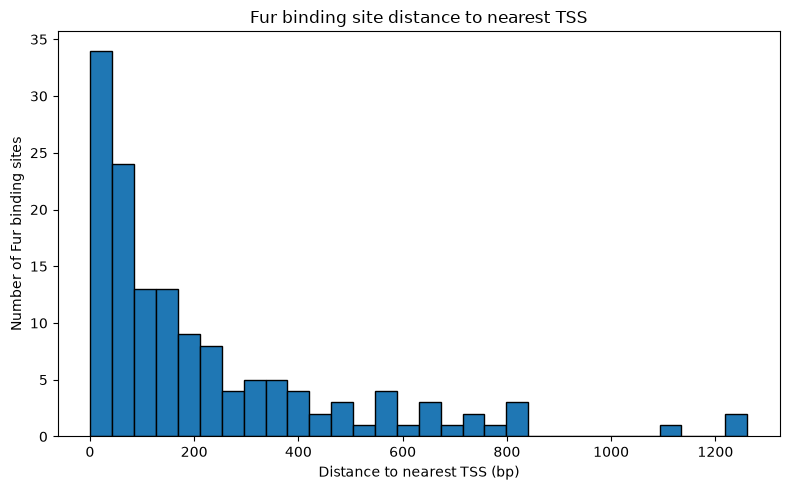

Histogram saved to ../data/reference/fur_tss_distance_histogram.png


In [11]:
# Prediction (Exercise 1 배경 기반):
# FUR가 주로 promoter/operator 부근에 결합해 RNAP 결합을 막거나(HR) 방해/보조하여(HA)
# repression/activation을 일으키므로, binding site-TSS 거리 분포는 0 근처에
# 뾰족한 피크가 몰릴 것으로 예상된다. 다만 논문에 따르면 binding site의 46%(55/119)가
# 애초에 regulatory region이 아닌 intragenic/converging 영역에 위치하므로,
# 0 근처 피크와 함께 먼 거리까지 이어지는 긴 tail도 함께 나타날 것이다.
#
# Genome-version sanity check: annotation GFF의 fhuA(b0150) start=167484가
# Exercise 5에서 추출한 fhuA 결합부위 midpoint(167461)와 근접(차이 23bp)하여,
# annotation과 .2 genome 좌표계가 서로 어긋나지 않았음을 확인했다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GFF_PATH = "../data/reference/ec_annotation_20100903_DHK_cSRNA_with_ortho.gff"
HIST_PATH = "../data/reference/fur_tss_distance_histogram.png"
TSS_DISTANCE_THRESHOLD = 500  # bp

# --- 1. Binding site: Exercise 5의 df(iron-replete 143개)를 재사용 ---
sites = df.copy()
sites["midpoint"] = ((sites["ChIP-exo Start"] + sites["ChIP-exo End"]) / 2)

# --- 2. Annotation GFF에서 gene별 TSS 유도 (+strand: start, -strand: end) ---
gff_cols = ["seqid", "source", "feature", "start", "end", "score", "strand", "frame", "attributes"]
genes = pd.read_csv(GFF_PATH, sep="\t", header=None, names=gff_cols)
genes["tss"] = np.where(genes["strand"] == "+", genes["start"], genes["end"])
tss_sorted = np.sort(genes["tss"].to_numpy())
print(f"Genes loaded: {len(genes)}")

# --- 3. 각 binding site 중심에서 가장 가까운 TSS까지 거리 계산 ---
def nearest_tss_distance(pos, sorted_tss):
    idx = np.searchsorted(sorted_tss, pos)
    candidates = []
    if idx > 0:
        candidates.append(abs(pos - sorted_tss[idx - 1]))
    if idx < len(sorted_tss):
        candidates.append(abs(pos - sorted_tss[idx]))
    return min(candidates)

sites["distance_to_tss"] = sites["midpoint"].apply(lambda p: nearest_tss_distance(p, tss_sorted))

# --- 4. 요약 통계 ---
print(f"Minimum distance: {sites['distance_to_tss'].min():.1f} bp")
print(f"Median distance: {sites['distance_to_tss'].median():.1f} bp")
within = (sites["distance_to_tss"] <= TSS_DISTANCE_THRESHOLD).sum()
print(f"Fraction within {TSS_DISTANCE_THRESHOLD} bp of a TSS: {within/len(sites):.3f} ({within}/{len(sites)})")

# --- 5. Cross-check: 논문 표의 Distance to TSS 컬럼과 비교 ---
paper_dist = pd.to_numeric(sites["Distance to TSS"], errors="coerce").abs()
mask = paper_dist.notna()
diff = sites.loc[mask, "distance_to_tss"] - paper_dist[mask]
print(f"\nCross-check ({mask.sum()} sites with paper value):")
print(f"  median |computed - paper| offset: {diff.abs().median():.1f} bp")

# --- 6. 히스토그램 ---
plt.figure(figsize=(8, 5))
plt.hist(sites["distance_to_tss"], bins=30, edgecolor="black")
plt.xlabel("Distance to nearest TSS (bp)")
plt.ylabel("Number of Fur binding sites")
plt.title("Fur binding site distance to nearest TSS")
plt.tight_layout()
plt.savefig(HIST_PATH, dpi=150)
plt.show()
print(f"Histogram saved to {HIST_PATH}")

**Cross-check 답변**

* 계산된 거리와 논문의 Distance to TSS 컬럼을 비교했을 때, 69개 site에서 median|computed − paper| offset이 47bp로 나타남. -> 이는 모든 site에서 균일하게 나타나는 offset이 아니라, site마다 편차가 있는 값임. => off-by-one이나 gemone-version mismatch로 보기 어려움
* 오히려 정의 차이로 설명하는 것이 타당함. 해당 스크립트는 genome-wide로 가장 가까운 TSS까지 순수 최단 거리를 계산하지만, 논문의 Distance to TSS는 각 binding site가 생물학적으로 지정된 특정 transcription unit의 TSS까지의 거리임. 즉 어떤 site는 물리적으로 가장 가까운 유전자가 아니라, divergent promoter나 operon 구조상 실제로 조절하는 유전자의 TSS까지 거리가 논문에 기록된 것일 수 있어 두 정의가 항상 일치하진 않는 것.

**Explain it**

* 이 스크립트는 Exercise 5에서 필터링한 143개 iron-replete binding site의 중심 과표((ChIP-exo start + ChIP-exo End)/2)를 계산 -> anntation GFF의 각 유전자에 대해 strand에 따라 TSS유도 -> np.searchsorted 로 정렬된 TSS 배열에서 각 Binding site 중심에 가장 가까운 TSS 찾음
* 4,595개 유전자 전체와 143개 site를 매번 전수비교하는 대신, TSS를 미리 정렬해두고 이진탐색(O(logN))을 쓴느 이유: 계산량을 크게 줄이면서도, "좌/우 중 더 가까운 쪽"이라는 로직을 구현할 수 있기 때문 
* 또한 genome version 문제를 시전에 배제하기 위해, 스크립트 실행 전, annotation fhuA(b0150) 좌표가 Exercise 5에서 뽑은 fhuA 결합부위 midpoint와 근접함을 확인해 aanotation과 .2genome 좌표계가 어긋나지 않음도 확인함. 


In [ ]:
# TSS distance analysis script.
# Prediction (write before running): ...



## 7. Integrative Visualization in MetaScope

So far this module produced three separate results: an **RNA-seq coverage** track (Section 2), a set of **Fur binding sites** (the table from Exercise 5), and a **motif** (Section 5). Each answers part of the FUR story, but the story only comes together when you see them **on the same axis**.

That is what MetaScope is for. In Module 3 you visualized a single ChIP-exo track. Here you'll overlay **three tracks** and read the regulation directly off the screen:

| Track | File | What it shows |
|-------|------|---------------|
| Gene annotation | `ec_annotation_20100903_DHK_cSRNA_with_ortho.gff` | Where the genes are |
| RNA-seq coverage | `rnaseq.gff` (your Exercise 2 output) | How strongly each region is transcribed |
| Fur binding sites | `fur_sites.gff` (you'll build it below) | Where FUR binds |

The biological payoff: at an iron-uptake gene, you should be able to see a **Fur binding site** sitting just upstream **and** ask whether the gene's **RNA-seq signal** is consistent with FUR's role as a repressor.

> As in Module 3, MetaScope runs on **your own computer**, not in the Codespace. Install it from the lab homepage ([sbml-lab.ai](https://sbml-lab.ai)). Produce the GFFs here, download them, then open them locally.

### Exercise 8 — Turn the Binding Sites into a Track

Your RNA-seq track and the annotation are already GFF files. The binding sites, though, are still rows in an Excel table — MetaScope can't read those. Convert them.

Use Claude Code to write a short script that reads the **iron-replete** binding sites (the `R` / `R/S` rows you filtered in Exercise 5) and writes a GFF file `data/reference/fur_sites.gff`, one row per site:

```
NC_000913	furchip	fur_site	<ChIP-exo Start>	<ChIP-exo End>	<S/N ratio>	.	.	name=<Transcription Unit>
```

Two things that matter (both are recurring themes in this course):
- **Chromosome ID must match the other tracks.** Use `NC_000913` in column 1 — the same ID the annotation and the `makegff.py` tracks use — so all tracks line up on the same view.
- **Put the S/N ratio in the score column** so stronger sites can be told apart when you display the track.

Write the script below, run it, and confirm `fur_sites.gff` has roughly one row per iron-replete site (~143).

In [12]:
# Exercise 8: iron-replete Fur binding site (143개)를 MetaScope용 GFF 트랙으로 변환

OUT_PATH = "../data/reference/fur_sites.gff"

with open(OUT_PATH, "w") as f:
    for _, row in df.iterrows():
        # ChIP-exo Start/End를 정수로 변환 (GFF 포맷은 정수 좌표를 요구)
        start = int(row["ChIP-exo Start"])
        end = int(row["ChIP-exo End"])

        # S/N ratio를 score column(6번째 필드)에 넣어서
        # MetaScope에서 결합 강도를 시각적으로(색/높이) 구분할 수 있게 함
        score = row["S/N ratio"]

        # Transcription Unit이 없는 행(NaN)은 name=nan으로 빠지지 않도록
        # 대신 Peak ID(P1, P2...)를 이름으로 사용 -> 143개 행 전부 유지
        name = row["Transcription Unit"] if pd.notna(row["Transcription Unit"]) else row["Peak"]

        # GFF 9-column 포맷으로 한 줄씩 작성
        # column 1: NC_000913 (버전 접미사 없이) -> annotation, rnaseq.gff와 동일한 ID로
        #           맞춰야 MetaScope에서 같은 화면에 세 트랙이 겹쳐서 보임
        # column 2: source (임의 라벨, "furchip")
        # column 3: feature type ("fur_site")
        # column 4~5: start, end 좌표
        # column 6: score (S/N ratio)
        # column 7~8: strand, frame -> 정보 없으므로 "."
        # column 9: attributes (name=...)
        f.write(f"NC_000913\tfurchip\tfur_site\t{start}\t{end}\t{score}\t.\t.\tname={name}\n")

print(f"{len(df)} rows written to {OUT_PATH}")

143 rows written to ../data/reference/fur_sites.gff


In [13]:
%%bash
# 파일이 143줄로 정확히 생성됐는지, 포맷이 맞는지 확인
wc -l ../data/reference/fur_sites.gff
head -3 ../data/reference/fur_sites.gff

143 ../data/reference/fur_sites.gff
NC_000913	furchip	fur_site	70524	70536	1.67	.	.	name=araC
NC_000913	furchip	fur_site	146494	146507	2.93	.	.	name=panD
NC_000913	furchip	fur_site	167242	167254	4.6	.	.	name=fhuACDB


### Exercise 9 — Overlay Three Tracks and Read the Regulation

On your machine, open MetaScope and load **all three** GFFs (`Ctrl/Cmd+O`): the annotation, `rnaseq.gff`, and `fur_sites.gff`.

1. **Pick a Fur-regulated iron gene.** Use `Ctrl/Cmd+F` to search the annotation, or `Ctrl/Cmd+G` to jump to a coordinate. Good candidates (verified in the lab annotation): **`fepA`** (~609–612 kb), the **`entCEBA`** enterobactin cluster (~624–629 kb), **`fhuA`** (~167 kb), or **`sodB`** (~1,733 kb).
2. **Line up the three tracks.** At your chosen gene, check: is there a **Fur binding site** just upstream? What does the **RNA-seq coverage** look like over the gene body?
3. **Note the RNA-seq condition.** FUR represses iron-uptake genes **when iron is replete**. Whether you expect high or low RNA-seq signal depends on the iron condition of the sample you aligned in Exercise 2 — state which condition it is and reason accordingly. (If you're unsure, that's a `/explain` or a quick check of the GSE54900 sample metadata.)
4. **Adjust the display** so the figure is readable: set distinct track colors (`Ctrl/Cmd+Shift+C`) and heights (`Ctrl/Cmd+Shift+H`), and scale the RNA-seq track so its peaks are visible.
5. **Export** (`Ctrl+Shift+E` → PNG, 300 dpi) as `module4_integrative_metascope.png`.

This exported figure is your Module 4 visualization deliverable.

> **Answer**
>
> - Gene chosen (name / locus_tag): fhuA/b0150
> - Is there a Fur binding site upstream of it? Position: Yes/ fur_sites.gff 기준 약 167,300~167,400bp 지점(exercise 5의 P4, midpoint=167,461)에 위치하며, fhuA gene start (167,484, +strand)보다 작은 좌표, 즉 upstream/promoter 방향에 해당함
> - RNA-seq condition of your sample (iron-replete / iron-depleted): iron-replete (SRR1168133)
> - Is the gene's RNA-seq signal consistent with FUR repression **under that condition**? Explain.
    > - * 예상과 다른 결과가 관찰됨. supplementary data1에 따르면 fhuA(P3)는 holo-Fur repression(HR)mode로 분류되어 있어 (S/N ratio=4.6), iron-replete조건에서는 FUR 결합에 의해 전사가 억제될 것으로 예상했음. 
    > - * 근데 MetaScope에서 fhuA 구간(167,500-169,700)의 RNA-seq(+) coverage를 보면, fur-sites 결합 부위 직후에 coverage가 짧게 떨어지만 이후 fhuA 유전자 전체에서는 오히려 스케일 최댓값(10.0)에 근사하게 높은 coverage가 유지됨. 이는 "억제되어 발현이 낮을 것"이라는 예측과는 반대임.
    > * 다만 이를 iron-replete 샘플 하나만으로 결론짓기는 어려움. coverage의 높이가 높다/낮다인지 판다나하려면 iron-deplete 조건 샘플과 비교가 필요하며, 이 비교 없이는 HR model 예측과의 일치/불일치를 확정할 수 없음. 이에 iron-delplete 샘플을 추가로 정렬하여 두 조건의 coverage를 비교해 볼 것.
> - Attach [module4_integrative_metascope.png](attachment:module4_integrative_metascope.png)

**Step1. 다운로드**

In [14]:
%%bash
# SRA toolkit 실행파일 경로를 PATH에 추가 (Codespace 셀은 매번 새 subprocess라 매번 필요)
export PATH="/opt/sratoolkit/bin:$PATH"

# Step 1: iron-depleted 조건 paired-end RNA-seq 샘플(SRR1168135) 다운로드
# --split-files: paired-end이므로 _1.fastq(R1) / _2.fastq(R2) 두 파일로 분리
# -O: 저장 위치 지정 (notebook cwd가 notebooks/ 이므로 ../data/reference/로 지정)
fasterq-dump --split-files SRR1168135 -O ../data/reference/

spots read      : 11,445,313
reads read      : 22,890,626
reads written   : 22,890,626


**Ste2. bowtie2 정렬**

In [1]:
%%bash
# SRR1168135(iron-depleted) paired-end 정렬
# Exercise 2와 동일한 플래그 사용 (조건만 다르고 파이프라인은 동일해야 두 결과가 비교 가능함)
# --very-fast: 속도 우선 preset
# -X 1000: mate 쌍 사이 최대 fragment 길이 1000bp (paired-end 전용)
# -3 3: read 3' 말단 3bp 트리밍 (품질 저하 구간 제거)
# -p 2: 스레드 2개
# --no-mixed: mate 한쪽만 정렬되면 결과에서 제외 (single-end fallback 금지)
# --no-discordant: 정렬은 됐지만 예상 방향/거리를 벗어난 쌍은 제외
bowtie2 --very-fast -X 1000 -3 3 -p 2 --no-mixed --no-discordant \
  -x ../data/reference/NC_000913.3 \
  -1 ../data/reference/SRR1168135_1.fastq -2 ../data/reference/SRR1168135_2.fastq \
  -S ../data/reference/SRR1168135.sam

[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
11445313 reads; of these:
  11445313 (100.00%) were paired; of these:
    143145 (1.25%) aligned concordantly 0 times
    11078936 (96.80%) aligned concordantly exactly 1 time
    223232 (1.95%) aligned concordantly >1 times
98.75% overall alignment rate


**Step3. SAM -> sorted, indexed BAM**

In [2]:
%%bash
# SAM을 BAM으로 변환 (-b: binary 출력, -S: 입력이 SAM임을 명시)
samtools view -bS ../data/reference/SRR1168135.sam -o ../data/reference/SRR1168135.bam

# coordinate 기준으로 정렬 (인덱싱하려면 정렬이 선행되어야 함)
samtools sort ../data/reference/SRR1168135.bam -o ../data/reference/SRR1168135_sorted.bam

# 정렬된 BAM에 .bai 인덱스 생성 (빠른 구간 조회를 위해 필요)
samtools index ../data/reference/SRR1168135_sorted.bam

[bam_sort_core] merging from 5 files and 1 in-memory blocks...


In [3]:
%%bash
# 세 파일(.bam, _sorted.bam, _sorted.bam.bai)이 모두 생성됐는지 확인
ls -lh ../data/reference/SRR1168135*.bam*

-rw-rw-rw- 1 vscode vscode 828M Aug 13 07:56 ../data/reference/SRR1168135.bam
-rw-rw-rw- 1 vscode vscode 522M Aug 13 07:57 ../data/reference/SRR1168135_sorted.bam
-rw-rw-rw- 1 vscode vscode  14K Aug 13 07:58 ../data/reference/SRR1168135_sorted.bam.bai


**Step4. makegff.py로 RNA-seq coverage GFF 생성**

In [4]:
%%bash
# SRR1168135(iron-depleted) sorted BAM을 RNA-seq coverage GFF로 변환
# --separate_strand: +/- strand를 별도 트랙으로 분리 (SRR1168133 때와 동일한 방식)
# --flip: RNA-seq는 라이브러리 준비 과정상 read가 원본 전사체와 반대 strand로 나오므로,
#         이를 뒤집어서 실제 전사 방향과 맞춤 (ChIP-exo는 이 옵션 불필요)
# --log_scale: score를 log2(count)로 스케일링. rRNA operon 등 극단적 outlier 때문에
#              적용하지 않으면 다른 유전자 신호가 다 묻힘
# 파일명을 rnaseq_depleted.gff로 지정 -> 기존 rnaseq.gff(iron-replete)와 구분
python ../makegff.py --separate_strand --flip --log_scale ../data/reference/SRR1168135_sorted.bam ../data/reference/rnaseq_depleted.gff

In [5]:
%%bash
# 결과 GFF 파일이 잘 생성됐는지 줄 수와 첫 몇 줄 확인
wc -l ../data/reference/rnaseq_depleted.gff
head -5 ../data/reference/rnaseq_depleted.gff

7898859 ../data/reference/rnaseq_depleted.gff
NC_000913		SRR1168135_sorted.bam_(-)	342	342	0.00	-	.	.
NC_000913		SRR1168135_sorted.bam_(-)	343	343	0.00	-	.	.
NC_000913		SRR1168135_sorted.bam_(-)	344	344	0.00	-	.	.
NC_000913		SRR1168135_sorted.bam_(-)	345	345	0.00	-	.	.
NC_000913		SRR1168135_sorted.bam_(-)	346	346	0.00	-	.	.


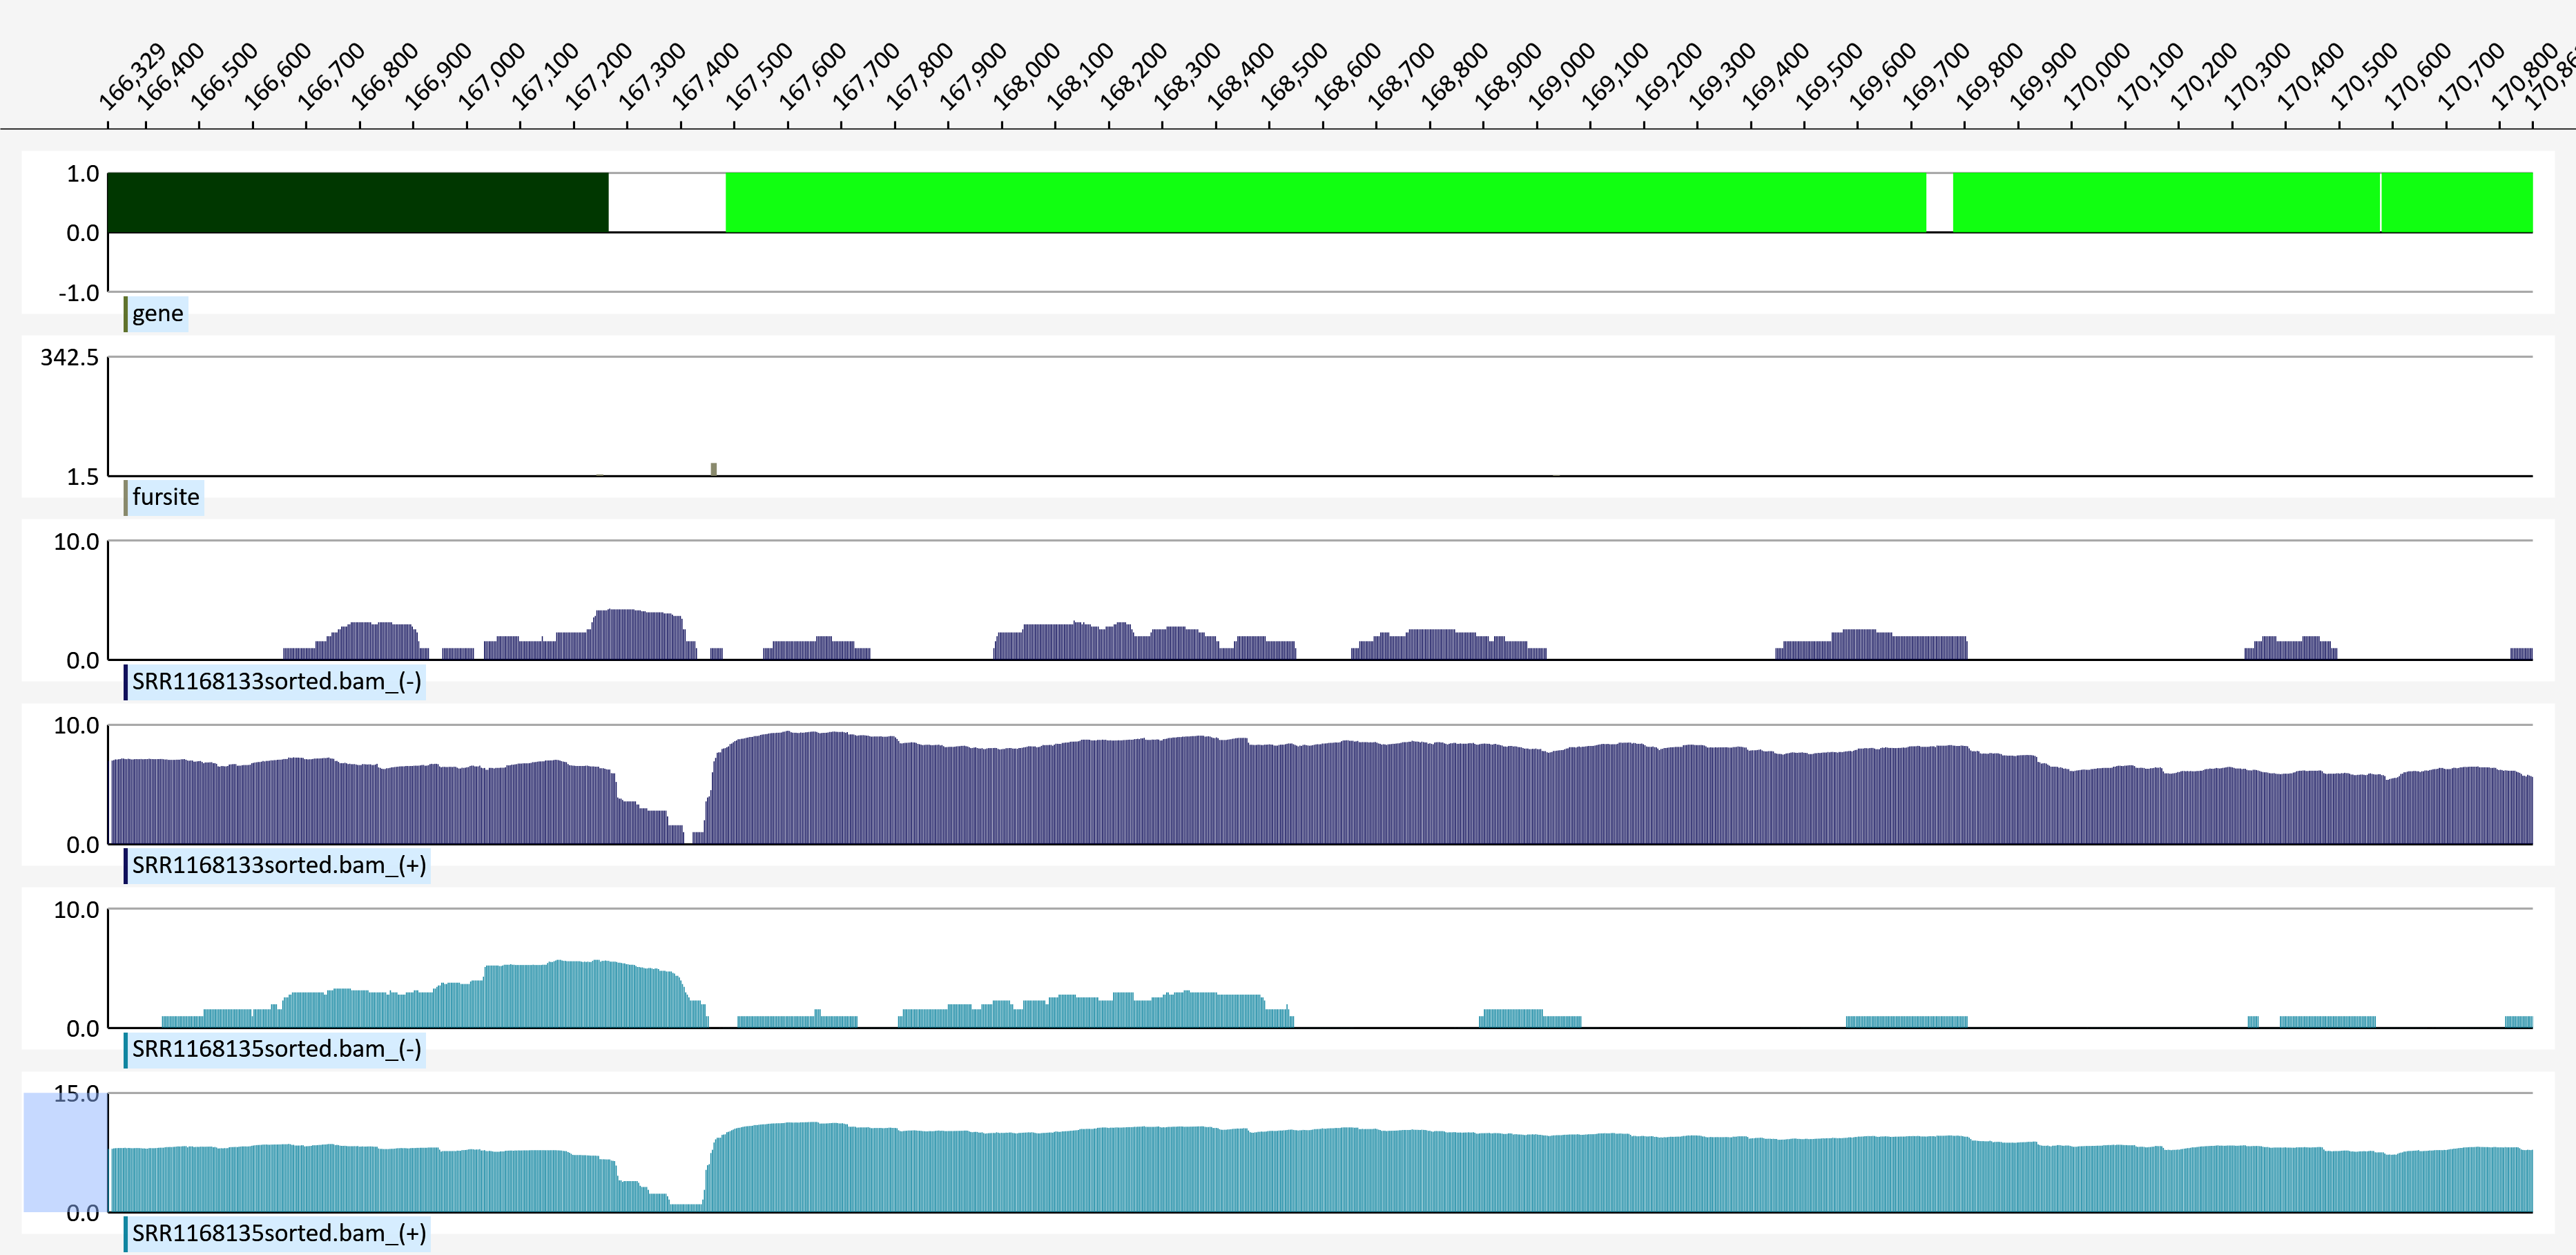

> **Expain it**
>
> iron-replete(SRR1168133) 샘플 하나만으로는 fhuA의 coverage가 절대적으로 "낮다"고 판단할 기준이 없었기 때문에, Exercise 2와 동일한 파이프라인(bowtie2 --very-fast -X 1000 -3 3 --no-mixed --no-discordant, makegff.py --separate_strand --flip --log_scale)으로 iron-depleted 조건의 SRR1168135를 추가로 정렬하여 rnaseq_depleted.gff를 생성했다. 두 조건을 MetaScope에 함께 로드하여 fhuA 구간을 나란히 비교한 결과, iron-depleted 조건의 coverage가 iron-replete 조건보다 명확히 높게(y축 스케일이 10에서 15로 확장될 만큼) 나타나, HR mode 예측과 일치하는 상대적 비교가 가능해졌다.

### Exercise 10 — Tie It Back to the Motif and the Literature

You now have three lines of evidence at one locus: a **binding site** (the track), a **motif** (Section 5 — is there a Fur box in that site's sequence?), and an **expression level** (the RNA-seq track). Together these are the core of what Seo et al. 2014 reported.

Write a short interpretation (3–5 sentences):
- Does the binding + expression pattern at your gene match FUR acting as an iron-responsive **repressor**?
- Is this **confirmatory** (a known FUR target), or did you land somewhere **unexpected** (FUR's "role beyond iron metabolism," as the paper's title puts it)?
- Use Claude Code to cross-check the gene's function and known FUR regulation — and note anything that *didn't* line up, and how you resolved it.

This is exactly the kind of integrative reading your mini-project (Module 5) will ask you to do independently.

> **Answer**
>
> fhuA(167,461bp upstream 결합, S/N=4.6, HR mode)는 Exercise 6의 MEME-1 Fur box 모티프에서 P-value 4.22×10⁻⁸로 뚜렷하게 검출되었고, RNA-seq 비교에서도 iron-depleted(SRR1168135) 조건이 iron-replete(SRR1168133) 조건보다 발현이 명확히 높아, 철이 충분할 때 FUR가 억제하고 부족할 때 억제가 풀린다는 HR 예측과 binding·motif·expression 세 증거가 모두 일치했다. Claude Code로 cross-check한 결과 fhuA는 페리크롬-Fe³⁺을 흡수하는 TonB-dependent 수용체(fhuACDB 오페론)이며, E. coli에서 가장 잘 특성화된 FUR target 중 하나로 ChIP-exo 연구의 positive control로 흔히 쓰인다는 점까지 확인되어, 세 증거와 문헌 사이에 불일치는 없었다. 즉 이번 사례는 명확한 confirmatory 사례이며, 논문 제목이 강조하는 "role beyond iron metabolism" 쪽 발견은 아니다. 다만 그만큼 파이프라인(binding→motif→expression) 전체가 정확히 작동함을 검증하는 좋은 기준점 역할을 했다.

## End of Module 4

You have completed:
- Reading and understanding a real ChIP-exo paper (Seo et al. 2014)
- Downloading and running a **paired-end RNA-seq** alignment, and producing a GFF track from it
- Using Biopython to pull binding-site sequences from a reference genome
- Running MEME and interpreting motif output
- Computing TSS distances as a downstream regulatory analysis
- **Overlaying annotation + RNA-seq + Fur binding sites in MetaScope** and reading the regulation integratively (`module4_integrative_metascope.png`)

---

Run `/log` before closing this session.

## Git — Commit Your Work

Every session ends with a commit. Run the commands below in your terminal (not in this notebook).

Write your own commit message following the format: `feat(module4): <what you did>`.  
If you're unsure what to write, ask Claude Code to suggest one based on what you worked on.

In [ ]:
# Run these in the terminal (not here):
# git add notebooks/
# git commit -m "..."   # write your own commit message; use Claude Code to help if needed
# git push


In [8]:
%%bash
# 이번 세션에서 생성한 주요 산출물들이 모두 존재하고 크기가 정상인지 확인
echo "=== Reference & genome ==="
ls -lh ../data/reference/NC_000913.2.fasta

echo -e "\n=== RNA-seq alignments ==="
ls -lh ../data/reference/SRR1168133_sorted.bam*
ls -lh ../data/reference/SRR1168135_sorted.bam*

echo -e "\n=== RNA-seq GFF tracks ==="
wc -l ../data/reference/rnaseq.gff
wc -l ../data/reference/rnaseq_depleted.gff

echo -e "\n=== Fur binding site sequences & GFF ==="
wc -l ../data/reference/fur_sites_for_meme.fasta
wc -l ../data/reference/fur_sites.gff

echo -e "\n=== MEME output ==="
ls -lh ../data/reference/meme_fur_out/meme.txt
ls -lh ../data/reference/meme_random_control/meme.txt

echo -e "\n=== MetaScope export ==="
ls -lh ../data/reference/module4_integrative_metascope*.png 2>/dev/null || echo "(로컬에만 저장되어 있다면 Codespace엔 없는 게 정상)"

=== Reference & genome ===
-rw-rw-rw- 1 vscode vscode 4.5M Aug 12 02:34 ../data/reference/NC_000913.2.fasta

=== RNA-seq alignments ===
-rw-rw-rw- 1 vscode vscode 468M Aug 11 07:31 ../data/reference/SRR1168133_sorted.bam
-rw-rw-rw- 1 vscode vscode  14K Aug 11 07:31 ../data/reference/SRR1168133_sorted.bam.bai
-rw-rw-rw- 1 vscode vscode 522M Aug 13 07:57 ../data/reference/SRR1168135_sorted.bam
-rw-rw-rw- 1 vscode vscode  14K Aug 13 07:58 ../data/reference/SRR1168135_sorted.bam.bai

=== RNA-seq GFF tracks ===
7261516 ../data/reference/rnaseq.gff
7898859 ../data/reference/rnaseq_depleted.gff

=== Fur binding site sequences & GFF ===
286 ../data/reference/fur_sites_for_meme.fasta
143 ../data/reference/fur_sites.gff

=== MEME output ===
-rw-rw-rw- 1 vscode vscode 67K Aug 11 08:33 ../data/reference/meme_fur_out/meme.txt
-rw-rw-rw- 1 vscode vscode 26K Aug 11 08:11 ../data/reference/meme_random_control/meme.txt

=== MetaScope export ===
(로컬에만 저장되어 있다면 Codespace엔 없는 게 정상)


In [9]:
%%bash
cd /workspaces/intern-claude-training

# 노트북과 이번 세션에서 새로 만든 GFF 산출물만 staging
# (BAM, fastq, fasta 같은 대용량 중간 파일은 .gitignore에 걸려있을 것으로 예상)
git add notebooks/04_multiomics_motif_with_claude.ipynb
git add data/reference/fur_sites.gff
git add data/reference/rnaseq.gff
git add data/reference/rnaseq_depleted.gff

git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   data/reference/fur_sites.gff
	new file:   data/reference/rnaseq.gff
	new file:   data/reference/rnaseq_depleted.gff
	modified:   notebooks/04_multiomics_motif_with_claude.ipynb

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   log/session-log.md
	modified:   notebooks/04_multiomics_motif_with_claude.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	CLAUDE.md
	data/reference/SRR1168121.fastq.gz
	data/reference/chipexo.gff
	data/reference/fur_tss_distance_histogram.png
	data/reference/meme_fur_out/
	data/reference/meme_random_control/
	data/reference/my_chipexo_test.gff
	data/reference/ncomms5910_SupplementaryData1_Fur_ChIPexo_binding_sites.xlsx



In [2]:
%%bash
# notebooks 폴더 안에 실제 png 파일이 있는지 확인
find /workspaces/intern-claude-training/notebooks -name "*.png"

In [3]:
%%bash
ls -lh /workspaces/intern-claude-training/notebooks/*.png

-rw-rw-rw- 1 vscode vscode 325K Aug 14 02:05 /workspaces/intern-claude-training/notebooks/module4_integrative_metascope.png
-rw-rw-rw- 1 vscode vscode 377K Aug 14 02:05 /workspaces/intern-claude-training/notebooks/module4_integrative_metascope_comparison.png
